In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [2]:
# 设置字符集，防止中文乱码
plt.rcParams['font.sans-serif']=[u'simHei']
plt.rcParams['axes.unicode_minus']=False

## 构造线性数据集

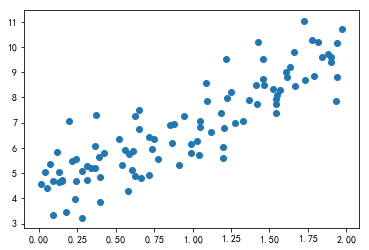

In [3]:
np.random.seed(42)
X = 2 * np.random.rand(100,1)
y = 4 + 3 * X + np.random.randn(100,1)
plt.scatter(X, y);
x_new = np.linspace(0,2,100)
plt.show()     #jupyter 中可以不要该命令

In [10]:
X.shape,y.shape,x_new.shape

((100, 1), (100, 1), (100,))

##  线性回归建模（最小二乘法）

In [4]:
# 利用正规矩阵求解
X_b = np.c_[np.ones((100, 1)), X]  # add x0 = 1 to each instance
x_new_b = np.c_[np.ones(100),x_new]

In [5]:
X_b.shape, x_new_b.shape

((100, 2), (100, 2))

In [6]:
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
theta_best

array([[4.21509616],
       [2.77011339]])

In [18]:
LinearRegression?
plt.xlabel?

In [15]:
#利用sklearn.LinearRegression求解
model = LinearRegression(fit_intercept=True)
model.fit(X,y) 
ypred = model.predict(x_new[:,np.newaxis])      #输入x必须是二维

In [16]:
print('截距项：{1},x的系数：{0}'.format(model.coef_,model.intercept_))

截距项：[4.21509616],x的系数：[[2.77011339]]


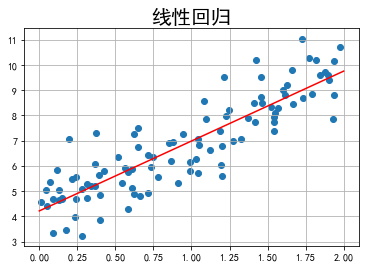

In [21]:
plt.scatter(X,y)
plt.plot(x_new,ypred,'r-');
#plt.ylabel('Y')
#plt.xlabel('X')
plt.title("线性回归", fontsize=20)
plt.grid()
plt.show()

## 使用批量梯度下降建模

In [23]:
eta = 0.1             #学习率
n_iterations = 100    #迭代遍数
m = 100
theta = np.random.randn(2,1)    #初始参数

for iteration in range(n_iterations):
    gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y)
    theta = theta - eta * gradients

In [29]:
theta

array([[ 0.62566735],
       [-0.85715756]])

In [27]:
#绘制随梯度下降的回归线变动图
def plot_gradient_descent(theta, eta):
    m = len(X_b)
    plt.scatter(X, y)
    n_epochs = 50
    for iteration in range(n_epochs):
        gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y)
        theta = theta - eta * gradients
        if  iteration <10:
            y_predict = x_new_b.dot(theta)
            plt.plot(x_new,y_predict)

    #画最终回归线
    y_predict = x_new_b.dot(theta)     
    plt.plot(x_new,y_predict,'r-',linewidth=6)
    
   # plt.ylabel("$Y$", rotation=0, fontsize=18)
    plt.axis([0, 2, 0, 15])
    plt.title(r"$\eta = {}$".format(eta), fontsize=16)

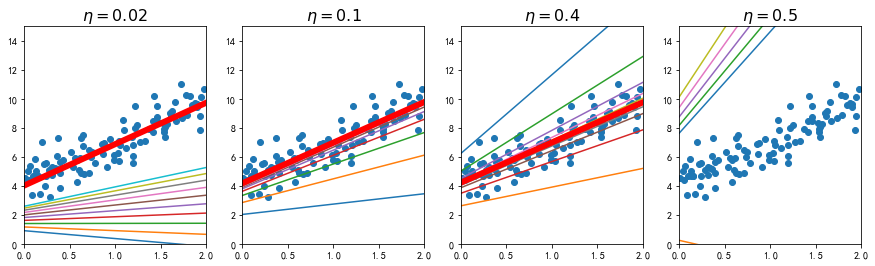

In [28]:
theta = np.random.randn(2,1)  # 初始化权重

plt.figure(figsize=(15,4))
plt.subplot(141); plot_gradient_descent(theta, eta=0.02)
plt.subplot(142); plot_gradient_descent(theta, eta=0.1)
plt.subplot(143); plot_gradient_descent(theta, eta=0.4)
plt.subplot(144); plot_gradient_descent(theta, eta=0.5)

## 使用随机梯度下降建模

[[4.21076011]
 [2.74856079]]


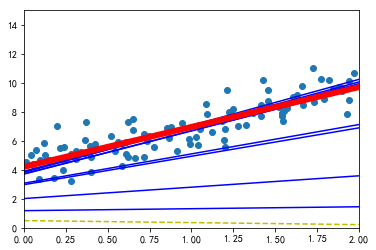

In [30]:
#手工计算

t0, t1 = 5, 50  # learning schedule hyperparameters  用于更新学习率

def learning_schedule(t):
    return t0 / (t + t1)


np.random.seed(42)
n_epochs = 50
theta = np.random.randn(2,1)  # 初始化权重
m =  100                      #观测数

plt.scatter(X, y)                                 
#plt.xlabel("$x$", fontsize=18)                    
#plt.ylabel("$y$", rotation=0, fontsize=18)           
plt.axis([0, 2, 0, 15])      

for epoch in range(n_epochs):
    for i in range(m):
        if epoch == 0 and i < 10:                    # 画出theta前10种取值对应的回归线
            y_predict = x_new_b.dot(theta)           
            style = "b-" if i > 0 else "y--"         
            plt.plot(x_new, y_predict, style)  
            
        random_index = np.random.randint(m)          #随机获取案例的索引
        xi = X_b[random_index:random_index+1]
        yi = y[random_index:random_index+1]
        gradients = 2 * xi.T.dot(xi.dot(theta) - yi)   #计算梯度
        eta = learning_schedule(epoch * m + i)         #计算学习率
        theta = theta - eta * gradients                #更新theta

y_predict = x_new_b.dot(theta)   
plt.plot(x_new, y_predict,'r-',linewidth=6);        #最终结果回归线    
print(theta)

In [68]:
#利用sklearn.linear_model.SGDRegressor
from sklearn.linear_model import  SGDRegressor

(array([2.79164828]), array([4.204494]))

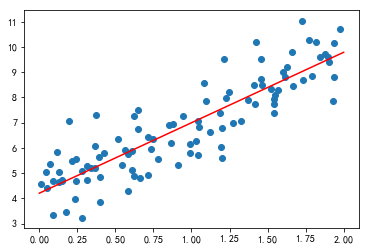

In [70]:
sgd_reg = SGDRegressor(max_iter=50,tol = 0.002,eta0=0.1)
sgd_reg.fit(X,y.ravel())
ypred = sgd_reg.predict(x_new[:,np.newaxis])
plt.scatter(X,y.ravel())
plt.plot(x_new,ypred,'r-');
sgd_reg.coef_,sgd_reg.intercept_

##  Mini-batch建模

[[4.2838122 ]
 [2.79430042]]


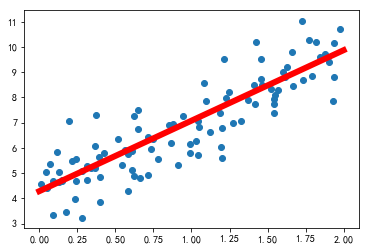

In [73]:
n_epochs = 50
minibatch_size = 10

np.random.seed(42)
theta = np.random.randn(2,1)  # random initialization

t0, t1 = 200, 1000
def learning_schedule(t):
    return t0 / (t + t1)

#t = 0
for epoch in range(n_epochs):
    #产生随机数索引,打乱原数据集中样本顺序
    shuffled_indices = np.random.permutation(m)
    X_b_shuffled = X_b[shuffled_indices]
    y_shuffled = y[shuffled_indices]
    for i in range(0, m, minibatch_size):  #逐个minibatch循环
        #t += 1
        xi = X_b_shuffled[i:i+minibatch_size]
        yi = y_shuffled[i:i+minibatch_size]

        gradients = 2/minibatch_size * xi.T.dot(xi.dot(theta) - yi)
        eta = learning_schedule(t)
        theta = theta - eta * gradients
        
plt.scatter(X,y.ravel())
y_predict = x_new_b.dot(theta)   
plt.plot(x_new, y_predict,'r-',linewidth=6);        #最终结果回归线    
print(theta)

## 构造非线性数据集

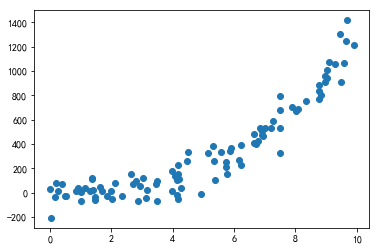

In [74]:
n=100
rng = np.random.RandomState(1)                        #rng为产生随机数得容器
x = 10 * rng.rand(n)                                  #一维数组 ,元素取值0-10之间   
x.sort()    
y2 = x**3+3*x**2-2*x-5+100*rng.randn(n)
plt.scatter(x,y2);

## 线性回归建模

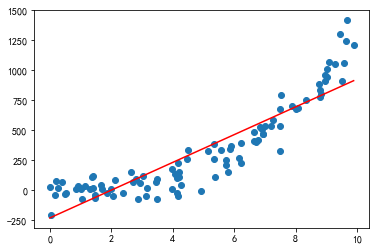

In [75]:
model2 = LinearRegression(fit_intercept=True)
model2.fit(x[:,np.newaxis],y2)
ypred2 = model2.predict(x[:,np.newaxis])
plt.scatter(x,y2);
plt.plot(x,ypred2,'r-');

## 多项式回归建模

In [76]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

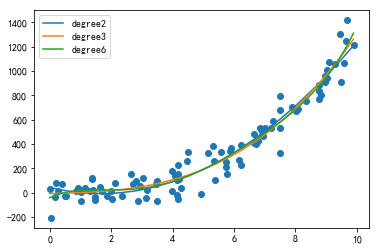

In [81]:
xx=x.copy()

plt.scatter(x,y2);
for degree in [2,3,6]:
    model3 = make_pipeline(PolynomialFeatures(degree),LinearRegression(fit_intercept=True))
    model3.fit(x[:,np.newaxis],y2)
    ypred3 = model3.predict(xx[:,np.newaxis])
    plt.plot(xx,ypred3,label='degree'+str(degree));

plt.legend();

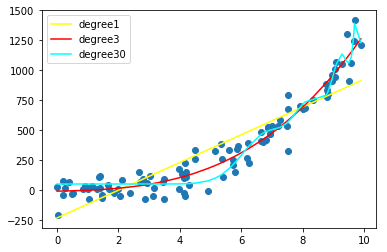

In [105]:
plt.scatter(x,y2);
for degree in [1,3,30]:
    model4 = make_pipeline(PolynomialFeatures(degree),LinearRegression(fit_intercept=True))
    model4.fit(x[:,np.newaxis],y2)
    ypred4 = model4.predict(xx[:,np.newaxis])
    if degree ==3:    
        plt.plot(xx,ypred4,label='degree'+str(degree),color='red');
    elif degree ==30:
        plt.plot(xx,ypred4,label='degree'+str(degree),color='cyan');
    else:
        plt.plot(xx,ypred4,label='degree'+str(degree),color='yellow');
plt.legend();

## hands on... 教材上的非线性数据

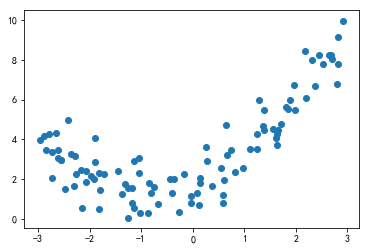

In [82]:
np.random.seed(42)
m=100
x = 6 * np.random.rand(m,1) -3
y =0.5 * x**2 +x +2 +np.random.randn(m,1)
plt.scatter(x,y);

In [83]:
x.shape,y.shape

((100, 1), (100, 1))

In [84]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

In [85]:
#查看加入指数的过程

poly_features = PolynomialFeatures(degree=2,include_bias=False)
xpoly = poly_features.fit_transform(x)
x[0],xpoly[0]

(array([-0.75275929]), array([-0.75275929,  0.56664654]))

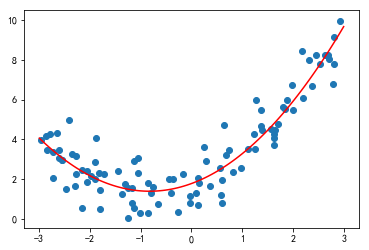

In [86]:
#对处理后的数据建立回归，并对新数据预测，作图

lin_reg = LinearRegression()
lin_reg.fit(xpoly,y)
xx = np.linspace(-3,3,100)
xx = xx.reshape(-1,1)                                 #变成二维
yy = lin_reg.predict(poly_features.fit_transform(xx))
plt.scatter(x,y)
plt.plot(xx,yy,'r-');

In [87]:
#查看模型参数
poly_features.get_feature_names(),lin_reg.coef_,lin_reg.intercept_

(['x0', 'x0^2'], array([[0.93366893, 0.56456263]]), array([1.78134581]))

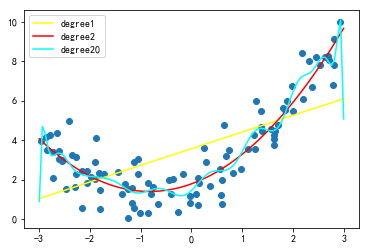

In [88]:
# 直接通过Pipeline 构造模型
plt.scatter(x,y);
for degree in [1,2,20]:
    model5 = make_pipeline(PolynomialFeatures(degree),LinearRegression(fit_intercept=True))
    model5.fit(x,y)
    ypred5 = model5.predict(xx)
    if degree ==2:    
        plt.plot(xx,ypred5,label='degree'+str(degree),color='red');
    elif degree ==20:
        plt.plot(xx,ypred5,label='degree'+str(degree),color='cyan');
    else:
        plt.plot(xx,ypred5,label='degree'+str(degree),color='yellow');
plt.legend();

## 标准化输入变量后建模

In [89]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [90]:
xx.shape

(100, 1)

[-3, 3, 0, 10]

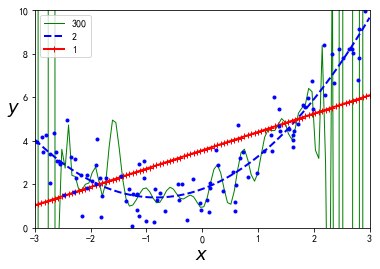

In [91]:
for style, width, degree in (("g-", 1, 300), ("b--", 2, 2), ("r-+", 2, 1)):
    polybig_features = PolynomialFeatures(degree=degree, include_bias=False)
    std_scaler = StandardScaler()
    lin_reg = LinearRegression()
    polynomial_regression = Pipeline([
            ("poly_features", polybig_features),
            ("std_scaler", std_scaler),
            ("lin_reg", lin_reg),
        ])
    polynomial_regression.fit(x, y)
    y_newbig = polynomial_regression.predict(xx)
    plt.plot(xx, y_newbig, style, label=str(degree), linewidth=width)

plt.plot(x, y, "b.", linewidth=3)
plt.legend(loc="upper left")
plt.xlabel("$x$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.axis([-3, 3, 0, 10])

## 以下绘制学习曲线

In [92]:
from sklearn.metrics import  mean_squared_error
from sklearn.model_selection import  train_test_split

In [94]:
#自定义绘制学习曲线
def plot_learning_curves(model,x,y):
    x_train,x_val,y_train,y_val = train_test_split(x,y,test_size=0.2)
    train_errors,val_errors =[],[]
    for m in range(1,len(x_train)):
        model.fit(x_train[:m],y_train[:m])
        y_trpred = model.predict(x_train[:m])
        y_vapred = model.predict(x_val[:m])
        train_errors.append(mean_squared_error(y_train[:m],y_trpred))
        val_errors.append(mean_squared_error(y_val[:m],y_vapred))
        
    plt.plot(np.sqrt(train_errors),'r-+',linewidth=2,label='train')
    plt.plot(np.sqrt(val_errors),'b-',linewidth=3,label='val')
    plt.legend()

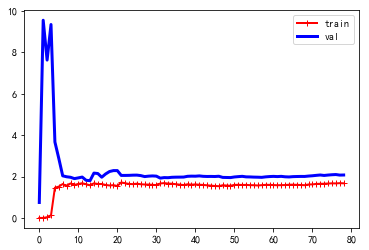

In [95]:
lin_reg = LinearRegression()
plot_learning_curves(lin_reg,x,y)

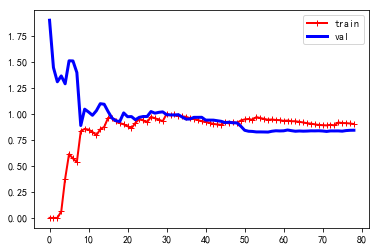

In [96]:
poly_reg = make_pipeline(PolynomialFeatures(2),LinearRegression(fit_intercept=True))
plot_learning_curves(poly_reg,x,y)

### sklearn中的学习曲线Learning Curve：评估样本量和指标的关系

In [98]:
from sklearn.model_selection import learning_curve,validation_curve
#from sklearn.learning_curve  import learning_curve,validation_curve   #老版本的sklearn

In [99]:
train_sizes,train_scores,test_scores=learning_curve(estimator=poly_reg,scoring='neg_mean_squared_error',X=x,y=y,cv=4)

In [103]:
x.shape,y.shape,train_sizes.shape,train_scores.shape,test_scores.shape
train_sizes

array([ 7, 24, 41, 58, 75])

In [104]:
train_mean= np.mean(train_scores,axis=1)
train_std = np.std(train_scores,axis=1)
test_mean =np.mean(test_scores,axis=1)
test_std=np.std(test_scores,axis=1)

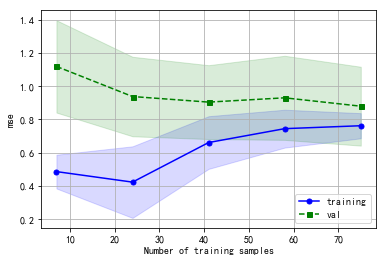

In [105]:
plt.plot(train_sizes,-train_mean,color='blue',marker='o',markersize=5,label='training')
plt.fill_between(train_sizes,-(train_mean+train_std),-(train_mean-train_std),alpha=0.15,color='blue')
plt.plot(train_sizes,-test_mean,color='green',linestyle='--',marker='s',markersize=5,label='val')
plt.fill_between(train_sizes,-(test_mean+test_std),-(test_mean-test_std),alpha=0.15,color='green')
plt.grid()
plt.xlabel('Number of training samples')
plt.ylabel('mse')
plt.legend(loc='lower right');

In [106]:
poly_reg.get_params().keys()

dict_keys(['memory', 'steps', 'polynomialfeatures', 'linearregression', 'polynomialfeatures__degree', 'polynomialfeatures__include_bias', 'polynomialfeatures__interaction_only', 'linearregression__copy_X', 'linearregression__fit_intercept', 'linearregression__n_jobs', 'linearregression__normalize'])

### 验证曲线validation Curve：评估超参和指标的关系

In [109]:
param_range=[1,2,3,5]
poly_reg1 = make_pipeline(PolynomialFeatures(),LinearRegression())
train_scores,test_scores =validation_curve(estimator=poly_reg1,X=x,y=y,param_name='polynomialfeatures__degree',param_range=param_range,cv=4)

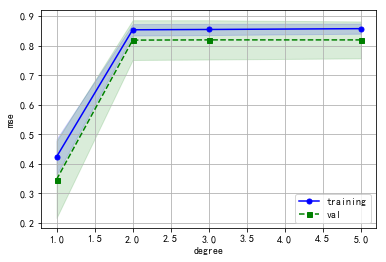

In [115]:
train_mean= np.mean(train_scores,axis=1)
train_std = np.std(train_scores,axis=1)
test_mean =np.mean(test_scores,axis=1)
test_std=np.std(test_scores,axis=1)
plt.plot(param_range,train_mean,color='blue',marker='o',markersize=5,label='training')
plt.fill_between(param_range,(train_mean+train_std),(train_mean-train_std),alpha=0.15,color='blue')
plt.plot(param_range,test_mean,color='green',linestyle='--',marker='s',markersize=5,label='val')
plt.fill_between(param_range,(test_mean+test_std),(test_mean-test_std),alpha=0.15,color='green')
plt.grid()
plt.xlabel('degree')
plt.ylabel('mse')
plt.legend(loc='lower right')

## 评估模型结果

In [139]:
poly_reg.fit(x,y)

Pipeline(memory=None,
     steps=[('polynomialfeatures', PolynomialFeatures(degree=2, include_bias=True, interaction_only=False)), ('linearregression', LinearRegression(copy_X=True, fit_intercept=True, n_jobs=1, normalize=False))])

In [140]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [147]:
y_pred = poly_reg.predict(x)
mse = mean_squared_error(y,y_pred)
print('mean_absolute_error:',mean_absolute_error(y,y_pred))
print('mse:',mse)
print('R2:',100-mse*100/y.var())

mean_absolute_error: 0.677864055434422
mse: 0.7771936663502366
R2: 85.25067519009745


## 正则化

In [116]:
from sklearn.linear_model import Ridge      
from sklearn.linear_model import LinearRegression

In [117]:
np.random.seed(42)
m = 20
X = 3 * np.random.rand(m, 1)
y = 1 + 0.5 * X + np.random.randn(m, 1) / 1.5
X_new = np.linspace(0, 3, 100).reshape(100, 1)

In [118]:
ridge_reg = Ridge(alpha=1)
ridge_reg.fit(X,y)
ridge_reg.coef_,ridge_reg.intercept_

(array([[0.36280369]]), array([1.00650911]))

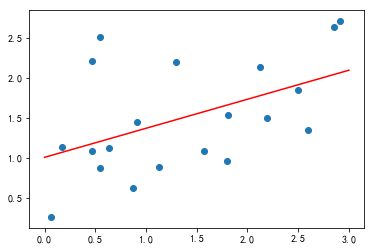

In [119]:
y_new = ridge_reg.predict(X_new)
plt.scatter(X, y)
plt.plot(X_new, y_new,'r'); 

In [120]:
#拟合模型并绘制回归线
def plot_model(model1, polynomial, alphas):    #polynomial是计算多项式特征， alphas为包含三个元素的元组
    for alpha, style in zip(alphas, ("b-", "g--", "r:")):
        if alpha > 0:
            model = model1(alpha)  
        else: 
            model = LinearRegression()
            
        if polynomial:
            model = Pipeline([
                    ("poly_features", PolynomialFeatures(degree=10, include_bias=False)),
                    ("std_scaler", StandardScaler()),
                    ("regul_reg", model),
                ])
        model.fit(X, y)
        y_new_regul = model.predict(X_new)
        
        lw = 2 if alpha > 0 else 1
        plt.plot(X_new, y_new_regul, style, linewidth=lw, label=r"$\alpha = {}$".format(alpha))
        
    plt.scatter(X, y)
    plt.xlabel("$x$", fontsize=18)
    plt.ylabel("$y$", rotation=0, fontsize=18)
    plt.axis([0, 3, 0, 4])
    plt.legend(loc="upper left", fontsize=15)

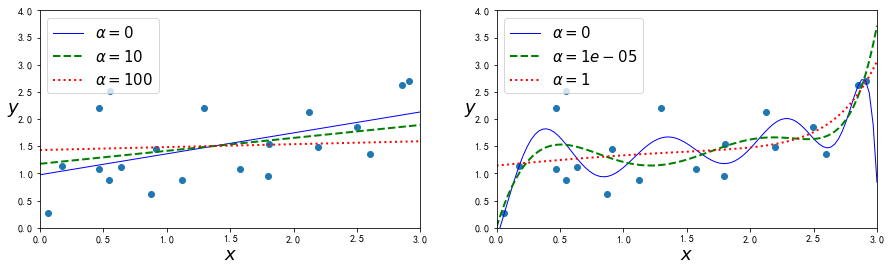

In [121]:
plt.figure(figsize=(15,4))
plt.subplot(121)
plot_model(Ridge, polynomial=False, alphas=(0, 10, 100))

plt.subplot(122)
plot_model(Ridge, polynomial=True, alphas=(0, 10**-5, 1))

[0.26167212] [1.14537356]


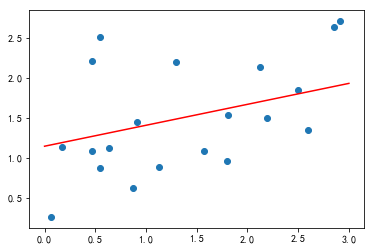

In [122]:
from sklearn.linear_model import Lasso
lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(X, y)

y_new = lasso_reg.predict(X_new)
plt.scatter(X, y)
plt.plot(X_new, y_new,'r'); 
print(lasso_reg.coef_,lasso_reg.intercept_)

[0.30462619] [1.08639303]


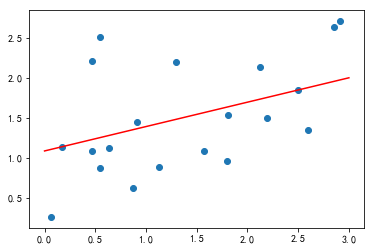

In [123]:
from sklearn.linear_model import ElasticNet
elastic_net = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic_net.fit(X, y)
y_new = elastic_net.predict(X_new)
plt.scatter(X, y)
plt.plot(X_new, y_new,'r'); 
print(elastic_net.coef_,elastic_net.intercept_)

## 绘制误差线

In [124]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures,StandardScaler
from sklearn.linear_model import  SGDRegressor
from sklearn.metrics import mean_squared_error

In [125]:
np.random.seed(42)
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 2 + X + 0.5 * X**2 + np.random.randn(m, 1)

In [126]:
X_train, X_val, y_train, y_val = train_test_split(X[:50], y[:50].ravel(), test_size=0.5, random_state=10)

In [128]:
poly_scaler = Pipeline([
        ("poly_features", PolynomialFeatures(degree=90, include_bias=False)),
        ("std_scaler", StandardScaler()),
    ])
x_poly_scaled = poly_scaler.fit_transform(X)
X_train_poly_scaled = poly_scaler.fit_transform(X_train)
X_val_poly_scaled = poly_scaler.transform(X_val)

In [129]:
sgd_reg = SGDRegressor(max_iter=1,
                       penalty='l1',
                       eta0=0.001,
                       warm_start=True,
                       learning_rate="constant",random_state=42)

n_epochs = 500
train_errors, val_errors = [], []
for epoch in range(n_epochs):
    sgd_reg.fit(X_train_poly_scaled, y_train)
    y_train_predict = sgd_reg.predict(X_train_poly_scaled)
    y_val_predict = sgd_reg.predict(X_val_poly_scaled)
    train_errors.append(mean_squared_error(y_train, y_train_predict))
    val_errors.append(mean_squared_error(y_val, y_val_predict))

best_epoch = np.argmin(val_errors)
best_val_rmse = np.sqrt(val_errors[best_epoch])

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\linear_model\stochastic_gradient.py:183: FutureWarning: max_iter and tol parameters have been added in SGDRegressor in 0.19. If max_iter is set but tol is left unset, the default value for tol in 0.19 and 0.20 will be None (which is equivalent to -infinity, so it has no effect) but will change in 0.21 to 1e-3. Specify tol to silence this warning.
  FutureWarning)
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\linear_model\stochastic_gradient.py:183: FutureWarning: max_iter and tol parameters have been added in SGDRegressor in 0.19. If max_iter is set but tol is left unset, the default value for tol in 0.19 and 0.20 will be None (which is equivalent to -infinity, so it has no effect) but will change in 0.21 to 1e-3. Specify tol to silence this warning.
  FutureWarning)
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\linear_model\stochastic_gradient.py:183: FutureWarning: max_iter and tol parameters have been added in SGDRegressor

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\linear_model\stochastic_gradient.py:183: FutureWarning: max_iter and tol parameters have been added in SGDRegressor in 0.19. If max_iter is set but tol is left unset, the default value for tol in 0.19 and 0.20 will be None (which is equivalent to -infinity, so it has no effect) but will change in 0.21 to 1e-3. Specify tol to silence this warning.
  FutureWarning)
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\linear_model\stochastic_gradient.py:183: FutureWarning: max_iter and tol parameters have been added in SGDRegressor in 0.19. If max_iter is set but tol is left unset, the default value for tol in 0.19 and 0.20 will be None (which is equivalent to -infinity, so it has no effect) but will change in 0.21 to 1e-3. Specify tol to silence this warning.
  FutureWarning)
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\linear_model\stochastic_gradient.py:183: FutureWarning: max_iter and tol parameters have been added in SGDRegressor

In [130]:
print("best epoch:",best_epoch,"     best_val_rmse : ",best_val_rmse)

best epoch: 119      best_val_rmse :  1.1686460797681009


Text(0, 0.5, 'RMSE')

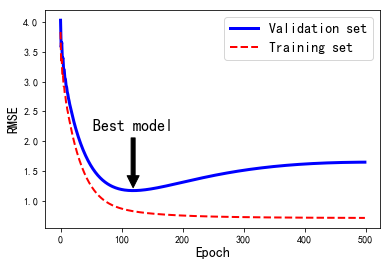

In [131]:
plt.annotate('Best model',
             xy=(best_epoch, best_val_rmse),
             xytext=(best_epoch, best_val_rmse + 1),
             ha="center",
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=16
            )        #图形加标记


plt.plot(np.sqrt(val_errors), "b-", linewidth=3, label="Validation set")
plt.plot(np.sqrt(train_errors), "r--", linewidth=2, label="Training set")
plt.legend(loc="upper right", fontsize=14)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("RMSE", fontsize=14)

In [132]:
from sklearn.model_selection import  GridSearchCV

In [297]:
param_grid=[{'eta0':[0.001,0.003],'max_iter':[200,230]}]

sgd_reg1 = SGDRegressor(penalty='l1', warm_start=True, random_state=42)
gsearch = GridSearchCV(sgd_reg1,param_grid,cv=3,scoring='neg_mean_squared_error',return_train_score=True)
gsearch.fit(x_poly_scaled, y.ravel())
print('best params:  ',gsearch.best_params_)
model = gsearch.best_estimator_

y_val_predict = model.predict(X_val_poly_scaled)
np.sqrt(mean_squared_error(y_val, y_val_predict))

best params:   {'eta0': 0.001, 'max_iter': 230}


1.1530525565079752